# Meine Pipelines

## Vorbereitung

In [2]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
scatter
sns.set_style("ticks")
plt.rc("axes.spines", top=False, right=False)
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = False
plt.rcParams["grid.color"] = "white"

In [239]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import KBinsDiscretizer

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [12]:
FILE_PATH = os.path.join("data", "flights.csv")

In [14]:
np.random.randn(42)
random.seed(42)

## Import

In [16]:
df_raw = pd.read_csv(FILE_PATH)

In [18]:
df_raw.head(5)

,Unnamed: 0,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01T10:00:00Z
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01T11:00:00Z


In [454]:
train_df, test_df = train_test_split(df_raw, random_state = 42)

In [689]:
time = ["time_hour", "hour", "minute"]
dates = ["year", "month", "day"]
cat_all = ["carrier", "tailnum", "origin", "dest"]
num_attributes = ["dep_delay","distance"]
target = ["arr_delay"]
delete = ["Unnamed: 0", "sched_dep_time", "sched_arr_time", "air_time", "flight", "tailnum", "year", "dep_time", "arr_time"]
corr = ["arr_delay", "month", "distance"]
cat_attributes = ["origin", "carrier"] 

## Inspect

In [133]:
df_raw["origin"].count()

336776

In [567]:
df_raw["tailnum"].nunique()

4043

In [139]:
df_raw["origin"].value_counts()

origin
EWR    120835
JFK    111279
LGA    104662
Name: count, dtype: int64

In [52]:
print(df_raw.shape) 

(336776, 20)


In [56]:
print(df_raw.dtypes)

Unnamed: 0          int64
year                int64
month               int64
day                 int64
dep_time          float64
sched_dep_time      int64
dep_delay         float64
arr_time          float64
sched_arr_time      int64
arr_delay         float64
carrier            object
flight              int64
tailnum            object
origin             object
dest               object
air_time          float64
distance            int64
hour                int64
minute              int64
time_hour          object
dtype: object


Zusammenhänge zwischen den numerischen Variablen

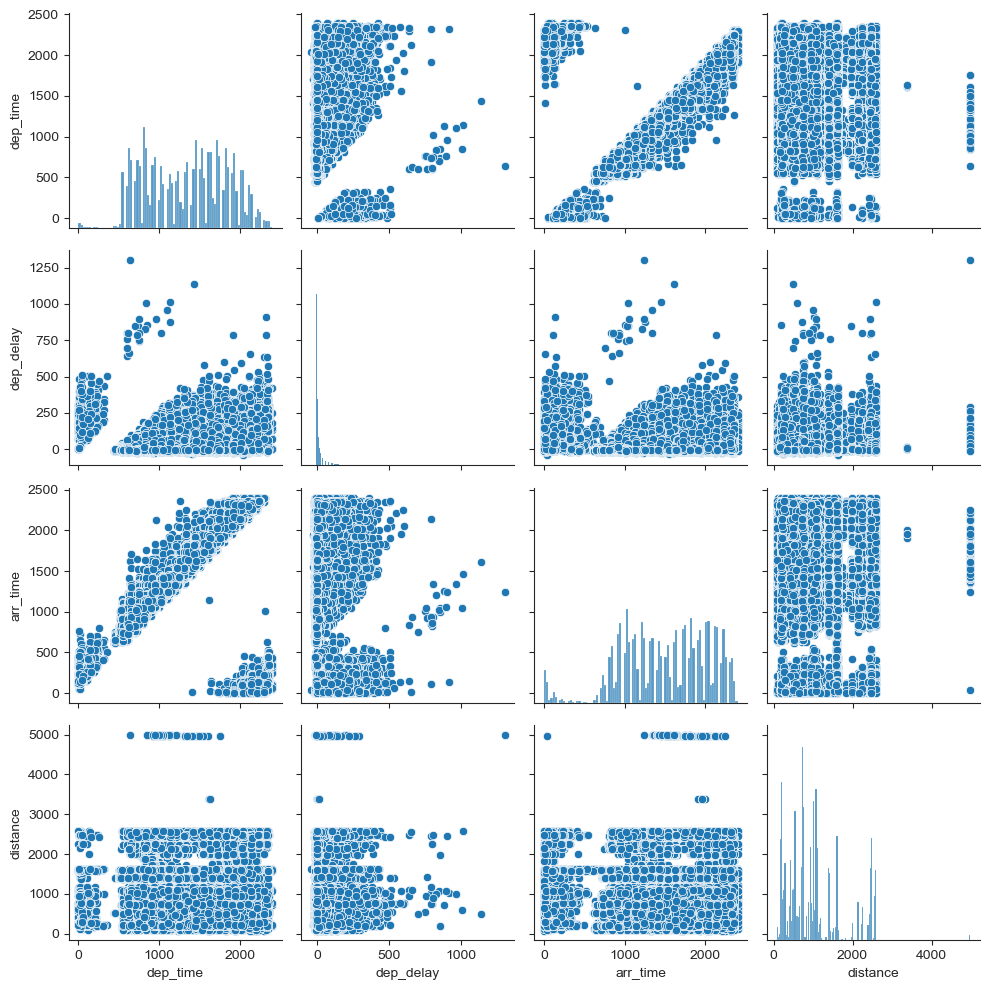

In [45]:
sns.pairplot(data=train_df[num])
plt.tight_layout()

Fehlende Werte

In [47]:
train_df.apply(lambda x: x.isnull().sum())

Unnamed: 0           0
year                 0
month                0
day                  0
dep_time          6168
sched_dep_time       0
dep_delay         6168
arr_time          6517
sched_arr_time       0
arr_delay         7048
carrier              0
flight               0
tailnum           1841
origin               0
dest                 0
air_time          7048
distance             0
hour                 0
minute               0
time_hour            0
dtype: int64

### Verteilung der Features prüfen

<Axes: ylabel='Frequency'>

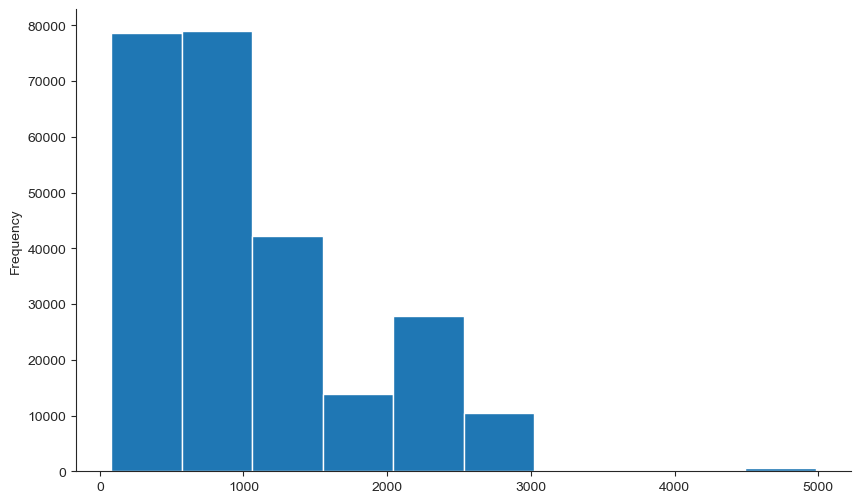

In [380]:
train_df["distance"].plot.hist()

### Verteilung des Targets "arr_delay"

<Axes: ylabel='Frequency'>

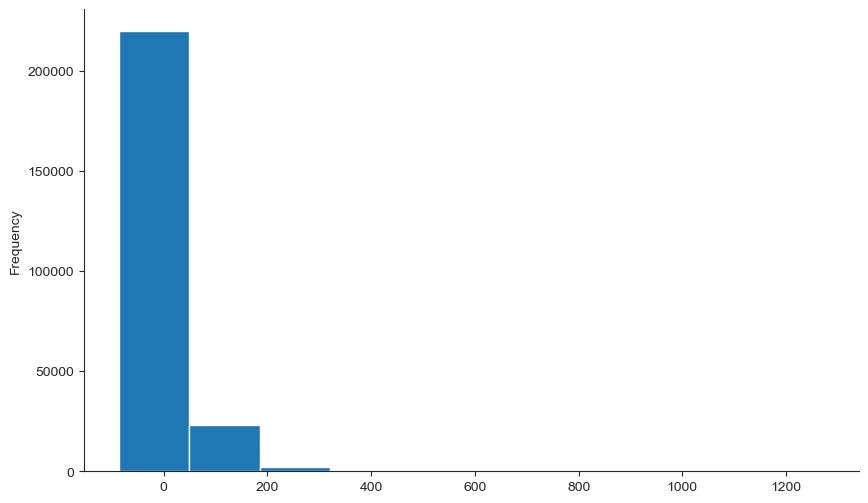

In [310]:
train_df["arr_delay"].plot.hist()

### Ergebnisse: Transform (& Data Engineering)

**Verteilung des Targets `arr_delay` nach log()-Transformation**

<Axes: ylabel='Frequency'>

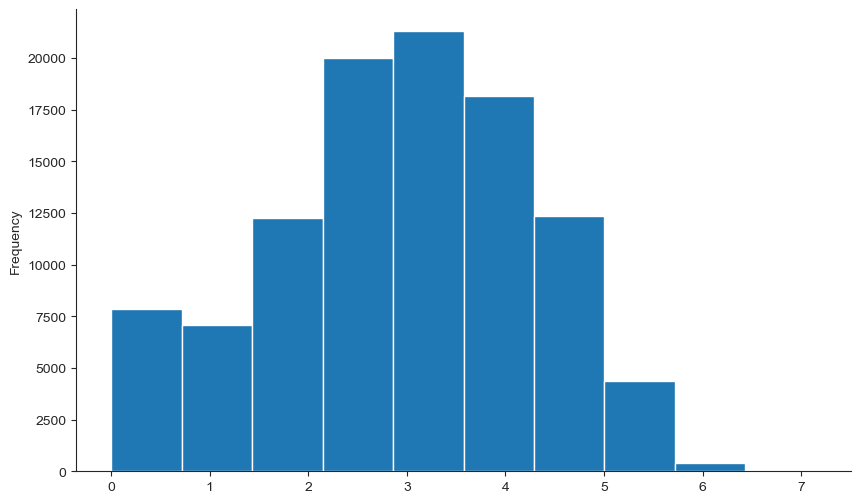

In [349]:
temp["log_arr_delay"].plot.hist()

**Korrelation zwischen numerische Variable**

In [125]:
train_df[corr].corr()

,arr_delay,month,distance
arr_delay,1.000000,-0.018411,-0.061796
month,-0.018411,1.000000,0.019899
distance,-0.061796,0.019899,1.000000


<Axes: >

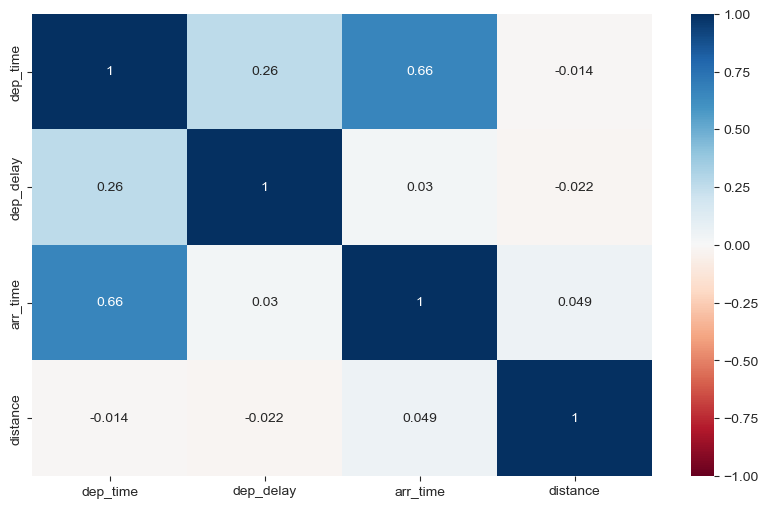

In [60]:
sns.heatmap(train_df[num].corr(), vmin=-1, vmax=1, cmap="RdBu", annot=True)

In [203]:
origin.corr()

,arr_delay,0,1,2
arr_delay,1.000000,0.037616,-0.021582,-0.016992
0,0.037616,1.000000,-0.527381,-0.499025
1,-0.021582,-0.527381,1.000000,-0.473102
2,-0.016992,-0.499025,-0.473102,1.000000


In [355]:
carrier2.corr()

,arr_delay,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
arr_delay,1.000000,0.002821,-0.049205,-0.016926,0.024852,-0.047554,0.085794,0.013613,0.028556,-0.008806,0.024371,0.002031,-0.033741,-0.027686,-0.014586,0.013243,0.008435
0,0.002821,1.000000,-0.077957,-0.011268,-0.105192,-0.097782,-0.101830,-0.010885,-0.023448,-0.007610,-0.068414,-0.002139,-0.109718,-0.060210,-0.029740,-0.046234,-0.009572
1,-0.049205,-0.077957,1.000000,-0.015645,-0.146054,-0.135766,-0.141387,-0.015113,-0.032556,-0.010566,-0.094990,-0.002969,-0.152339,-0.083599,-0.041293,-0.064194,-0.013290
2,-0.016926,-0.011268,-0.015645,1.000000,-0.021111,-0.019624,-0.020436,-0.002184,-0.004706,-0.001527,-0.013730,-0.000429,-0.022019,-0.012084,-0.005969,-0.009279,-0.001921
3,0.024852,-0.105192,-0.146054,-0.021111,1.000000,-0.183196,-0.190781,-0.020392,-0.043930,-0.014258,-0.128174,-0.004007,-0.205558,-0.112805,-0.055719,-0.086620,-0.017933
4,-0.047554,-0.097782,-0.135766,-0.019624,-0.183196,1.000000,-0.177341,-0.018956,-0.040835,-0.013253,-0.119145,-0.003725,-0.191078,-0.104858,-0.051794,-0.080518,-0.016670
5,0.085794,-0.101830,-0.141387,-0.020436,-0.190781,-0.177341,1.000000,-0.019741,-0.042526,-0.013802,-0.124078,-0.003879,-0.198989,-0.109200,-0.053939,-0.083852,-0.017360
6,0.013613,-0.010885,-0.015113,-0.002184,-0.020392,-0.018956,-0.019741,1.000000,-0.004546,-0.001475,-0.013263,-0.000415,-0.021270,-0.011672,-0.005765,-0.008963,-0.001856
7,0.028556,-0.023448,-0.032556,-0.004706,-0.043930,-0.040835,-0.042526,-0.004546,1.000000,-0.003178,-0.028571,-0.000893,-0.045820,-0.025145,-0.012420,-0.019308,-0.003997
8,-0.008806,-0.007610,-0.010566,-0.001527,-0.014258,-0.013253,-0.013802,-0.001475,-0.003178,1.000000,-0.009273,-0.000290,-0.014871,-0.008161,-0.004031,-0.006267,-0.001297


**Korrelationsanalyse nach Transformationen**

In [368]:
temp_corr = temp[["log_arr_delay", "month"]]
temp_corr.corr()

,log_arr_delay,month
log_arr_delay,1.000000,-0.020474
month,-0.020474,1.000000


## Transform

### Kategorische Variable in numerische Umwandeln (dummies)

**origin**

In [388]:
origin = train_df.loc[:, ["origin", "arr_delay"]]
origin = origin.dropna()
origin = origin.reset_index(drop=True)
origin_input = origin["origin"].copy()

In [179]:
one_hot = OneHotEncoder().fit_transform(origin_input.to_frame()).toarray()
one_hot = pd.DataFrame(one_hot)
origin = origin.merge(one_hot, right_index=True, left_index=True)

In [197]:
origin = origin.drop(columns="origin")

In [ ]:
one_hot = OneHotEncoder().fit_transform(origin_input.to_frame()).toarray()
one_hot = pd.DataFrame(one_hot)

### Funktion OneHotEncoder

In [607]:
def var_input (var):
    var_ob = train_df.loc[:, [var, "log_arr_delay"]]
    var_ob = var_ob.dropna()
    var_ob = var_ob.reset_index(drop=True)
    var_ob_input = var_ob[var].copy()

    #Konvertierung zu einer numerischen Variable
    one_hot = OneHotEncoder().fit_transform(var_ob_input.to_frame()).toarray()
    one_hot = pd.DataFrame(one_hot)
    var_ob = var_ob.merge(one_hot, right_index=True, left_index=True)

    #erste Spalte entfernen
    var_ob = var_ob.drop(columns=[var])

    return var_ob

### log() und quantile-Transformation des Targets

**log()-Transformation**

In [337]:
temp = train_df.copy()

In [339]:
temp = temp[temp["arr_delay"] >= 0]

In [341]:
temp["log_arr_delay"] = np.log1p(temp["arr_delay"])

In [605]:
train_df["log_arr_delay"] = np.log1p(temp["arr_delay"])

### Pipelines erstellen

#### Datensatz für die Pipeline vorbereiten

In [691]:
def prepare_for_pipeline(df):
    print("Original shape:", df.shape)
    df = df[num_attributes + cat_attributes + target]
    print("Shape after feature selection:", df.shape)
    df = df.dropna()
    print("Shape after dropna():", df.shape)
    return df, df[target]

In [693]:
train_df_pre, y_train = prepare_for_pipeline(train_df)

Original shape: (252582, 21)
Shape after feature selection: (252582, 5)
Shape after dropna(): (245534, 5)


In [695]:
train_df_pre.head()

,dep_delay,distance,origin,carrier,arr_delay
84848,10.0,589,JFK,9E,-5.0
256642,167.0,2248,JFK,DL,137.0
335647,-2.0,292,LGA,9E,-19.0
291502,-4.0,1089,JFK,DL,17.0
334470,-4.0,198,LGA,EV,1.0


#### numerische Pipelines

In [697]:
num_pipeline = Pipeline(
    [
        ("std_scaler", StandardScaler()),
    ]
)   

#### kategorische Pipelines

In [716]:
full_pipeline = ColumnTransformer(
    [
        ("num", num_pipeline, num_attributes),
        ("cat", OneHotEncoder(sparse_output=False), cat_attributes),
    ]
)

In [718]:
X_train = full_pipeline.fit_transform(train_df_pre)

In [720]:
pd.DataFrame(X_train).head(5)

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,-0.064689,-0.623958,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3.844270,1.630865,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.363462,-1.027625,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.413258,0.055615,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.413258,-1.155385,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [724]:
feature_names = full_pipeline.get_feature_names_out()
feature_names

array(['num__dep_delay', 'num__distance', 'cat__origin_EWR',
       'cat__origin_JFK', 'cat__origin_LGA', 'cat__carrier_9E',
       'cat__carrier_AA', 'cat__carrier_AS', 'cat__carrier_B6',
       'cat__carrier_DL', 'cat__carrier_EV', 'cat__carrier_F9',
       'cat__carrier_FL', 'cat__carrier_HA', 'cat__carrier_MQ',
       'cat__carrier_OO', 'cat__carrier_UA', 'cat__carrier_US',
       'cat__carrier_VX', 'cat__carrier_WN', 'cat__carrier_YV'],
      dtype=object)

## Analysis

### Feature Korrelation mit Target ("arr_delay")

#### origin

In [609]:
origin = var_input("origin")
origin.corr()

,log_arr_delay,0,1,2
log_arr_delay,1.000000,0.029323,-0.003856,-0.026983
0,0.029323,1.000000,-0.534907,-0.509301
1,-0.003856,-0.534907,1.000000,-0.454692
2,-0.026983,-0.509301,-0.454692,1.000000


#### carrier

In [612]:
carrier = var_input("carrier")
carrier.corr()

,log_arr_delay,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
log_arr_delay,1.000000,0.037069,-0.016849,-0.005494,0.009320,-0.038019,0.082416,0.005239,-0.002245,-0.008585,-0.008947,0.004945,-0.024492,-0.056367,-0.009375,-0.003903,0.011239
0,0.037069,1.000000,-0.068173,-0.009211,-0.106335,-0.086670,-0.108740,-0.012494,-0.027556,-0.006189,-0.071811,-0.001890,-0.103151,-0.055872,-0.026901,-0.046973,-0.009985
1,-0.016849,-0.068173,1.000000,-0.011855,-0.136852,-0.111544,-0.139948,-0.016080,-0.035465,-0.007965,-0.092420,-0.002432,-0.132754,-0.071907,-0.034621,-0.060454,-0.012850
2,-0.005494,-0.009211,-0.011855,1.000000,-0.018491,-0.015071,-0.018909,-0.002173,-0.004792,-0.001076,-0.012487,-0.000329,-0.017937,-0.009716,-0.004678,-0.008168,-0.001736
3,0.009320,-0.106335,-0.136852,-0.018491,1.000000,-0.173982,-0.218286,-0.025081,-0.055316,-0.012423,-0.144154,-0.003794,-0.207066,-0.112159,-0.054001,-0.094295,-0.020044
4,-0.038019,-0.086670,-0.111544,-0.015071,-0.173982,1.000000,-0.177918,-0.020442,-0.045087,-0.010126,-0.117496,-0.003092,-0.168773,-0.091417,-0.044015,-0.076857,-0.016337
5,0.082416,-0.108740,-0.139948,-0.018909,-0.218286,-0.177918,1.000000,-0.025648,-0.056568,-0.012704,-0.147415,-0.003880,-0.211750,-0.114696,-0.055223,-0.096428,-0.020497
6,0.005239,-0.012494,-0.016080,-0.002173,-0.025081,-0.020442,-0.025648,1.000000,-0.006500,-0.001460,-0.016938,-0.000446,-0.024330,-0.013178,-0.006345,-0.011079,-0.002355
7,-0.002245,-0.027556,-0.035465,-0.004792,-0.055316,-0.045087,-0.056568,-0.006500,1.000000,-0.003219,-0.037357,-0.000983,-0.053660,-0.029065,-0.013994,-0.024436,-0.005194
8,-0.008585,-0.006189,-0.007965,-0.001076,-0.012423,-0.010126,-0.012704,-0.001460,-0.003219,1.000000,-0.008390,-0.000221,-0.012051,-0.006528,-0.003143,-0.005488,-0.001167


#### Month

In [614]:
corr_month = train_df[["log_arr_delay","month"]]
corr_month.corr()

,log_arr_delay,month
log_arr_delay,1.000000,-0.020474
month,-0.020474,1.000000


## Review

## Export